# Importations

In [ ]:
# Numerical and scientific python programming
import numpy as np

from scipy.stats import unitary_group

import matplotlib.pyplot as plt

# Local importations
from moments.bloch import compute_pauli_basis, compute_tensor_basis, compute_subset_index_map, compute_bloch_norms_from_dm
from moments.quantum import generate_rand_dm, generate_GHZ_state, compute_outer_product

# Auxiliary functions 

In [ ]:
def compute_sector_lengths(N, tensor_basis, subset_index_map, rho):
    R = compute_bloch_norms_from_dm(tensor_basis, subset_index_map, rho)
    R[()] = 1.0
    
    S = {n: 0 for n in range(0, N+1)}

    subset_index_map[()] = np.array([0])
    for subset in subset_index_map.keys():
        S[len(subset)] += float(R[subset])**2
    return S

# Definitions

In [3]:
dn = 2

pauli_basis = compute_pauli_basis()

canonical_basis = [np.array([[1], [0]]), np.array([[0], [1]])]

## N = 4

In [4]:
N = 4
dim = [dn]*N

local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

In [ ]:
psi = [generate_GHZ_state(n) for n in range(1, N+1)]

rho = [compute_outer_product(psi_n, psi_n) for psi_n in psi]

RHO = [
    np.kron(rho[0], np.kron(rho[0], np.kron(rho[0], rho[0]))),
    np.kron(rho[1], np.kron(rho[0], rho[0])),
    np.kron(rho[1], rho[1]),
    np.kron(rho[2], rho[0]),
    rho[3]
]

S = [compute_sector_lengths(N, tensor_basis, subset_index_map, phi) for phi in RHO]

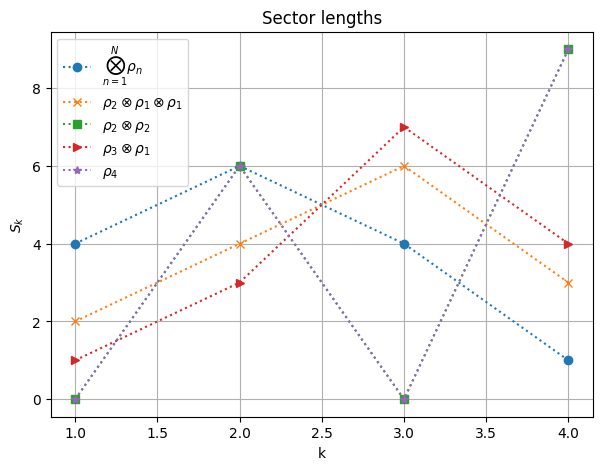

In [6]:
labels = [
    r"$\bigotimes_{n = 1}^{N} \rho_{n}$",
    r"$\rho_{2} \otimes \rho_{1} \otimes \rho_{1}$",
    r"$\rho_{2} \otimes \rho_{2}$",
    r"$\rho_{3} \otimes \rho_{1}$",
    r"$\rho_{4}$",
    ]
markers = ["o", "x", "s", ">", "*"]

fig, ax = plt.subplots(figsize=(7, 5))

for i, s in enumerate(S):
    ax.plot(range(1, N+1), list(s.values())[1:], label = labels[i], linestyle = 'dotted', marker = markers[i])

ax.set(xlabel = "k", ylabel = r"$S_k$", title = "Sector lengths")
ax.legend()

ax.grid(True)

plt.show()

## N = 5

In [7]:
N = 5
dim = [dn]*N

local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

In [ ]:
psi = [generate_GHZ_state(n) for n in range(1, N+1)]

rho = [compute_outer_product(psi_n, psi_n) for psi_n in psi]

RHO = [
    np.kron(rho[0], np.kron(rho[0], np.kron(rho[0], np.kron(rho[0], rho[0])))),
    np.kron(rho[1], np.kron(rho[0], np.kron(rho[0], rho[0]))),
    np.kron(rho[1], np.kron(rho[1], rho[0])),
    np.kron(rho[2], np.kron(rho[0], rho[0])),
    np.kron(rho[2], rho[1]),
    np.kron(rho[3], rho[0]),
    rho[4]
]

S = [compute_sector_lengths(N, tensor_basis, subset_index_map, phi) for phi in RHO]

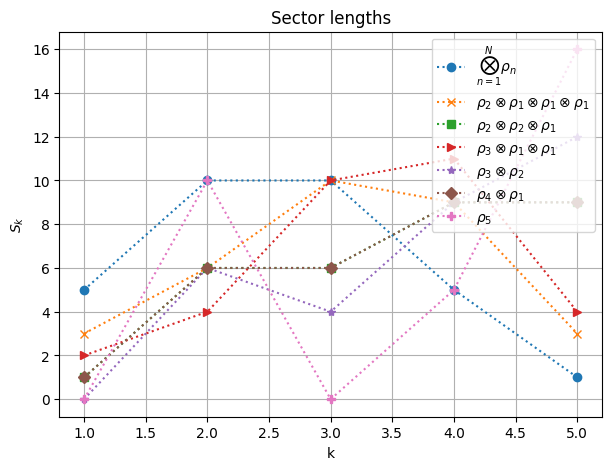

In [9]:
labels = [
    r"$\bigotimes_{n = 1}^{N} \rho_{n}$",
    r"$\rho_{2} \otimes \rho_{1} \otimes \rho_{1} \otimes \rho_{1}$",
    r"$\rho_{2} \otimes \rho_{2} \otimes \rho_{1}$",
    r"$\rho_{3} \otimes \rho_{1} \otimes \rho_{1}$",
    r"$\rho_{3} \otimes \rho_{2}$",
    r"$\rho_{4} \otimes \rho_{1}$",
    r"$\rho_{5}$",
    ]
markers = ["o", "x", "s", ">", "*", "D", "P"]

fig, ax = plt.subplots(figsize=(7, 5))

for i, s in enumerate(S):
    ax.plot(range(1, N+1), list(s.values())[1:], label = labels[i], linestyle = 'dotted', marker = markers[i])

ax.set(xlabel = "k", ylabel = r"$S_k$", title = "Sector lengths")
ax.legend(loc="upper right")

ax.grid(True)

plt.show()

# Convolutional property

Given the Hilbert space $\mathcal H$ with dimension $d$ and any bipartition $P$, $Q$ such that $\mathcal H = \mathcal H_P \otimes \mathcal H_Q$ with dimensions $d = d_P + d_Q$; and the product state $\varrho = \varrho_P \otimes \varrho_Q$ with $\varrho_P \in \mathcal H_P$ and $\varrho_Q \in \mathcal H_Q$; then the sector length of $\varrho$ can be written as

$$
S_k (\varrho) = \sum_{j = 0}^k S_j (\varrho_P) S_{k - j}(\varrho_Q) \, .
$$

In [10]:
def compute_sector_length_conv(N, S_Q, S_P):
	
    S_P_enlarged = {k: S_P.get(k, 0) for k in range(0, N + 1)}
    S_Q_enlarged = {k: S_Q.get(k, 0) for k in range(0, N + 1)}
    
    S = {}

    for k in range(0, N + 1):
        
        S_k = 0
        
        for j in range(0, k + 1):
            
            S_k += S_P_enlarged[j] * S_Q_enlarged[k - j]
        
        S[k] = S_k
    
    return S

In [ ]:
M = 250
N_P, N_Q = 2, 3
N = N_P + N_Q

dim_P, dim_Q = [dn]*N_P, [dn]*N_Q
dim = dim_P + dim_Q

d_P, d_Q = int(np.prod(dim_P)), int(np.prod(dim_Q))
d = int(d_P * d_Q)

local_bases_P, local_bases_Q = [pauli_basis.copy()] * N_P, [pauli_basis.copy()] * N_Q
local_basis_sizes_P, local_basis_sizes_Q = [len(basis) for basis in local_bases_P], [len(basis) for basis in local_bases_Q]

local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis_P, tensor_basis_Q = compute_tensor_basis(local_bases_P), compute_tensor_basis(local_bases_Q)
subset_index_map_P, subset_index_map_Q = compute_subset_index_map(local_basis_sizes_P), compute_subset_index_map(local_basis_sizes_Q)

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

DS = []

for m in range(M):

    rho_P, rho_Q = generate_rand_dm(d_P, d_P), generate_rand_dm(d_Q, d_Q)
    rho = np.kron(rho_Q, rho_P)

    S_P = compute_sector_lengths(N_P, tensor_basis_P, subset_index_map_P, rho_P)
    S_Q = compute_sector_lengths(N_Q, tensor_basis_Q, subset_index_map_Q, rho_Q)

    S = compute_sector_lengths(N, tensor_basis, subset_index_map, rho)
    S_conv = compute_sector_length_conv(N, S_Q, S_P)

    DS.append(np.sum(np.abs(np.array(list(S.values())) - np.array(list(S_conv.values())))))

print(f"The final absolute error after the $M$ random initializations is {np.sum(DS)}.")


The final absolute error after the $M$ random initializations is $\Delta S = 1.2755074774162267e-13$.
